# 線形回帰の解釈

## t検定

In [5]:
import pandas as pd
df = pd.read_csv('../data/sample_data2.csv')
y_col = 'rent'
X = df.drop(columns=[y_col])
y = df[y_col]

In [18]:
# 線形回帰
import statsmodels.api as sma
X = sma.add_constant(X)
est = sma.OLS(y, X)
est_trained = est.fit()
est_trained.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   rent   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     32.66
Date:                Sat, 09 May 2026   Prob (F-statistic):           0.000282
Time:                        07:21:58   Log-Likelihood:                -22.687
No. Observations:                  10   AIC:                             51.37
Df Residuals:                       7   BIC:                             52.28
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.4150      2.043      3.140      0.016       1.584      11.246
space          0.2677      0.035      7.622      0.000       0.185       0.351
age            0.1206      0.131      0.924      0.386      -0.188       0.429
==============================================================================
Omnibus:                        0.981   Durbin-Watson:                   2.514
Prob(Omnibus):                  0.612   Jarque-Bera (JB):                0.734
Skew:                          -0.364   Prob(JB):                        0.693
Kurtosis:                       1.890   Cond. No.                         130.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

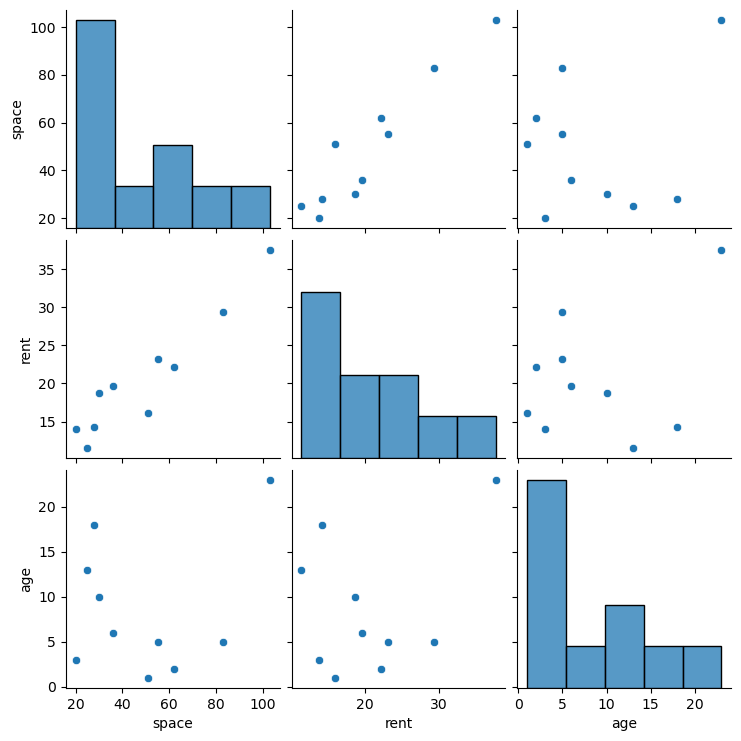

In [19]:
import seaborn as sns
sns.pairplot(df)

In [21]:
# 標準化
from sklearn.preprocessing import StandardScaler
X = df.drop(columns=[y_col])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = sma.add_constant(X_scaled)
X_scaled

array([[ 1.        , -1.13466215, -0.8062772 ],
       [ 1.        , -0.9410338 ,  0.63350351],
       [ 1.        , -0.82485679,  1.35339387],
       [ 1.        , -0.74740544,  0.2015693 ],
       [ 1.        , -0.51505142, -0.37434298],
       [ 1.        ,  0.06583364, -1.09423334],
       [ 1.        ,  0.22073632, -0.51832106],
       [ 1.        ,  0.49181602, -0.95025527],
       [ 1.        ,  1.3050551 , -0.51832106],
       [ 1.        ,  2.07956852,  2.07328422]])

In [22]:
est = sma.OLS(y, X_scaled)
est_trained = est.fit()
est_trained.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   rent   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     32.66
Date:                Sat, 09 May 2026   Prob (F-statistic):           0.000282
Time:                        07:35:50   Log-Likelihood:                -22.687
No. Observations:                  10   AIC:                             51.37
Df Residuals:                       7   BIC:                             52.28
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         20.6474      0.884     23.355      0.000      18.557      22.738
x1             6.9115      0.907      7.622      0.000       4.767       9.056
x2             0.8377      0.907      0.924      0.386      -1.307       2.982
==============================================================================
Omnibus:                        0.981   Durbin-Watson:                   2.514
Prob(Omnibus):                  0.612   Jarque-Bera (JB):                0.734
Skew:                          -0.364   Prob(JB):                        0.693
Kurtosis:                       1.890   Cond. No.                         1.25
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""